# Bike Sharing Demand
## 从时间序列看城市出行规律 — 共享单车需求预测


In [1]:
# === 基础库 ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# === 中文字体 ===
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# === 可视化设置 ===
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("基础库加载完成")

基础库加载完成


In [2]:
# 加载数据
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
print(f'训练集: {train.shape}')
print(f'测试集: {test.shape}')
train.head(3)

训练集: (10886, 12)
测试集: (6493, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


---

## 第 1 章 · 问题定义


### 1.1 任务描述

共享单车运营商需要提前知道"未来一小时某区域大概会租出多少辆车"，以便调配车辆、避免站点空置或堆积。Kaggle 提供了 Capital Bikeshare（华盛顿 DC）2011-2012 年的租车记录，我们用它来训练预测模型。

- **训练集**：10,886 条（每小时一条，每月前 19 天）
- **测试集**：6,493 条（每月 20 日到月底）
- **特征**：时间戳 + 季节/天气/温湿度/风速等 9 个字段
- **目标**：`count`（该小时的总租车数）


### 1.2 评估指标：RMSLE

Kaggle 用 **RMSLE**（Root Mean Squared Logarithmic Error）来评估：

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(\log(y_i^{pred} + 1) - \log(y_i^{true} + 1)\right)^2}$$

跟常规的 RMSE 比，RMSLE 有两个特点：

1. **对大值和小值公平** — 取对数后，预测 500 辆时差 10 辆和预测 10 辆时差 1 辆的惩罚量级差不多。如果不取对数，模型会拼命拟合高峰时段而忽略深夜
2. **`+1` 的意义** — 避免 `log(0)` 炸掉（确实存在租车数为 0 的小时）

对建模的直接影响：**训练时对 `count` 做 `log1p` 变换，用 RMSE 作为损失函数，预测时 `expm1` 还原**。

In [3]:
# RMSLE 评估函数
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

print("RMSLE 评估函数已定义")

RMSLE 评估函数已定义


### 1.3 分析视角

一个城市的共享单车数据，本质上是用车记录了一座城市的作息规律。早高峰的骑行者是通勤族，下午两点骑行的是游客或自由职业者，深夜还在骑车的人有他们自己的故事。

接下来的分析不会只盯模型分数。我希望从数据里看到：**华盛顿 DC 的人什么时候出门、天气如何改变出行决策、通勤者和休闲骑行者的行为差异有多大**。

---

## 第 2 章 · 探索性数据分析（EDA）


In [4]:
# 解析 datetime 字段（仅用于 EDA）
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

# 提取时间分量
train['hour'] = train['datetime'].dt.hour
train['day'] = train['datetime'].dt.day
train['weekday'] = train['datetime'].dt.dayofweek
train['month'] = train['datetime'].dt.month
train['year'] = train['datetime'].dt.year

print(f'时间范围: {train["datetime"].min()} ~ {train["datetime"].max()}')
print(f'年份: {train["year"].unique()}')
train[["datetime", "season", "holiday", "workingday", "weather"]].head(5)

时间范围: 2011-01-01 00:00:00 ~ 2012-12-19 23:00:00
年份: [2011 2012]


,datetime,season,holiday,workingday,weather
0,2011-01-01 00:00:00,1,0,0,1
1,2011-01-01 01:00:00,1,0,0,1
2,2011-01-01 02:00:00,1,0,0,1
3,2011-01-01 03:00:00,1,0,0,1
4,2011-01-01 04:00:00,1,0,0,1


### 2.1 数据总览


In [5]:
# 基本信息
print("=== 数据类型 ===")
print(train.dtypes)
print(f"\n=== 缺失值 ===")
print(train.isnull().sum())
print(f"\n=== 描述统计 ===")
train.describe()

=== 数据类型 ===
datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
hour                   int32
day                    int32
weekday                int32
month                  int32
year                   int32
dtype: object

=== 缺失值 ===
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
hour          0
day           0
weekday       0
month         0
year          0
dtype: int64

=== 描述统计 ===


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day,weekday,month,year
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399412,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,11.541613,9.992559,3.013963,6.521495,2011.501929
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2011.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,6.000000,5.000000,1.000000,4.000000,2011.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,12.000000,10.000000,3.000000,7.000000,2012.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,18.000000,15.000000,5.000000,10.000000,2012.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,23.000000,19.000000,6.000000,12.000000,2012.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,6.915838,5.476608,2.004585,3.444373,0.500019


确认：**本数据集无缺失值**。`count` 的分布需要进一步分析。

---

### 2.2 目标变量分布


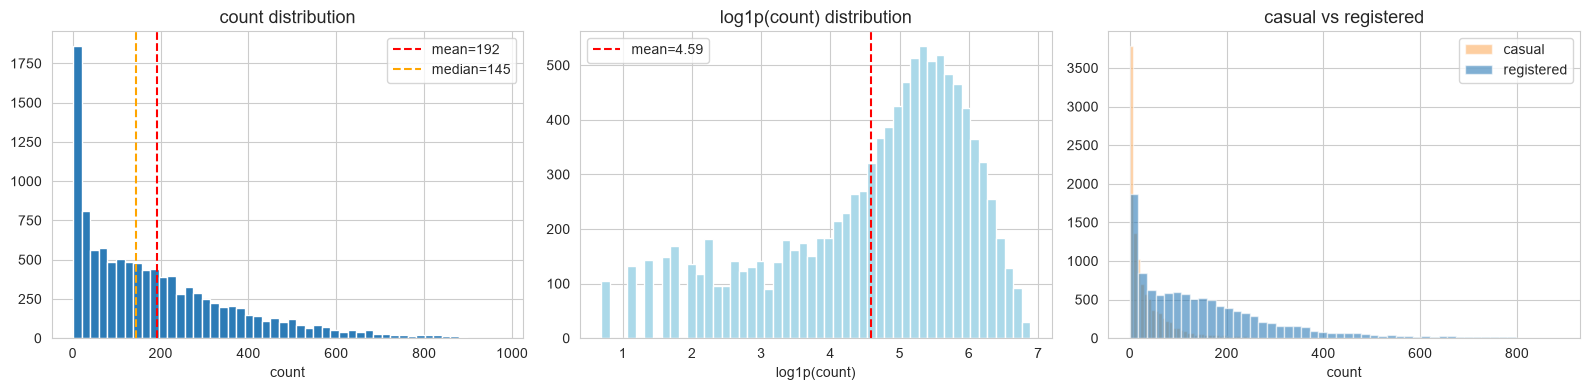

count mean=192, median=145, std=181
casual share: 18.8%
registered share: 81.2%
hours with count=0: 0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 直方图
axes[0].hist(train["count"], bins=50, edgecolor="white", color="#2c7bb6")
axes[0].axvline(train["count"].mean(), color="red", linestyle="--",
               label=f'mean={train["count"].mean():.0f}')
axes[0].axvline(train["count"].median(), color="orange", linestyle="--",
               label=f'median={train["count"].median():.0f}')
axes[0].set_title("count distribution", fontsize=13)
axes[0].set_xlabel("count")
axes[0].legend()

# log1p 变换后
log_count = np.log1p(train["count"])
axes[1].hist(log_count, bins=50, edgecolor="white", color="#abd9e9")
axes[1].axvline(log_count.mean(), color="red", linestyle="--",
               label=f'mean={log_count.mean():.2f}')
axes[1].set_title("log1p(count) distribution", fontsize=13)
axes[1].set_xlabel("log1p(count)")
axes[1].legend()

# casual vs registered
axes[2].hist(train["casual"], bins=50, alpha=0.6, label="casual", color="#fdae61")
axes[2].hist(train["registered"], bins=50, alpha=0.6, label="registered", color="#2c7bb6")
axes[2].set_title("casual vs registered", fontsize=13)
axes[2].set_xlabel("count")
axes[2].legend()

plt.tight_layout()
plt.savefig("output/figures/count-distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f'count mean={train["count"].mean():.0f}, median={train["count"].median():.0f}, std={train["count"].std():.0f}')
print(f'casual share: {train["casual"].sum() / train["count"].sum() * 100:.1f}%')
print(f'registered share: {train["registered"].sum() / train["count"].sum() * 100:.1f}%')
print(f'hours with count=0: {(train["count"] == 0).sum()}')

`count` 呈典型的右偏分布 — 绝大多数时段租车量在 200 以下，极少数高峰超过 800。**log1p 变换后接近正态**，验证了用 log 空间建模的合理性。

registered 用户是主体（占约 82%），但 casual 有自己的行为模式，后面展开分析。

---

### 2.3 时间模式：小时 × 工作日

把一天 24 小时拉出来，按工作日/周末分开看——这是整份数据里信号最强的维度。

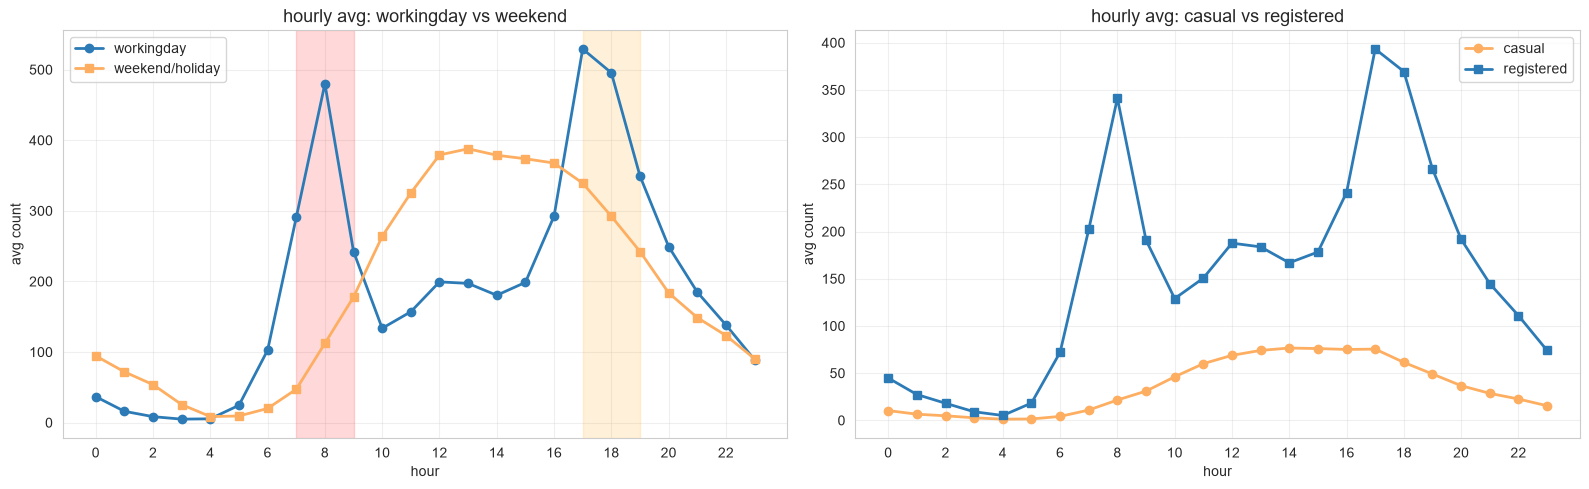

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 工作日 vs 周末的每小时平均
wd = train[train["workingday"] == 1].groupby("hour")["count"].mean()
we = train[train["workingday"] == 0].groupby("hour")["count"].mean()

hours = range(24)
axes[0].plot(hours, wd, "o-", color="#2c7bb6", lw=2, ms=6, label="workingday")
axes[0].plot(hours, we, "s-", color="#fdae61", lw=2, ms=6, label="weekend/holiday")
axes[0].axvspan(7, 9, alpha=0.15, color="red")
axes[0].axvspan(17, 19, alpha=0.15, color="orange")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("avg count")
axes[0].set_title("hourly avg: workingday vs weekend", fontsize=13)
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# casual vs registered 分时
ch = train.groupby("hour")["casual"].mean()
rh = train.groupby("hour")["registered"].mean()
axes[1].plot(hours, ch, "o-", color="#fdae61", lw=2, ms=6, label="casual")
axes[1].plot(hours, rh, "s-", color="#2c7bb6", lw=2, ms=6, label="registered")
axes[1].set_xlabel("hour")
axes[1].set_ylabel("avg count")
axes[1].set_title("hourly avg: casual vs registered", fontsize=13)
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output/figures/hourly-patterns.png", dpi=150, bbox_inches="tight")
plt.show()

从小时模式能读出几个关键信息：

1. **工作日有两个尖峰** — 早 7-9 点和晚 17-19 点，典型的通勤潮汐。registered 用户是这两个尖峰的主力
2. **周末只有一个缓坡** — 从上午 10 点到下午 5 点维持高位，没有明显的早晚割裂
3. **casual 用户集中在白天** — 尤其是周末的下午，凌晨到清晨几乎为零
4. **深夜（0-5 点）租车量趋于 0** — 这个时段的预测难度最低

对特征工程的启示很明显：`hour` 是最重要的信号，但需要和 `workingday` 一起用。

---

### 2.4 季节与月份


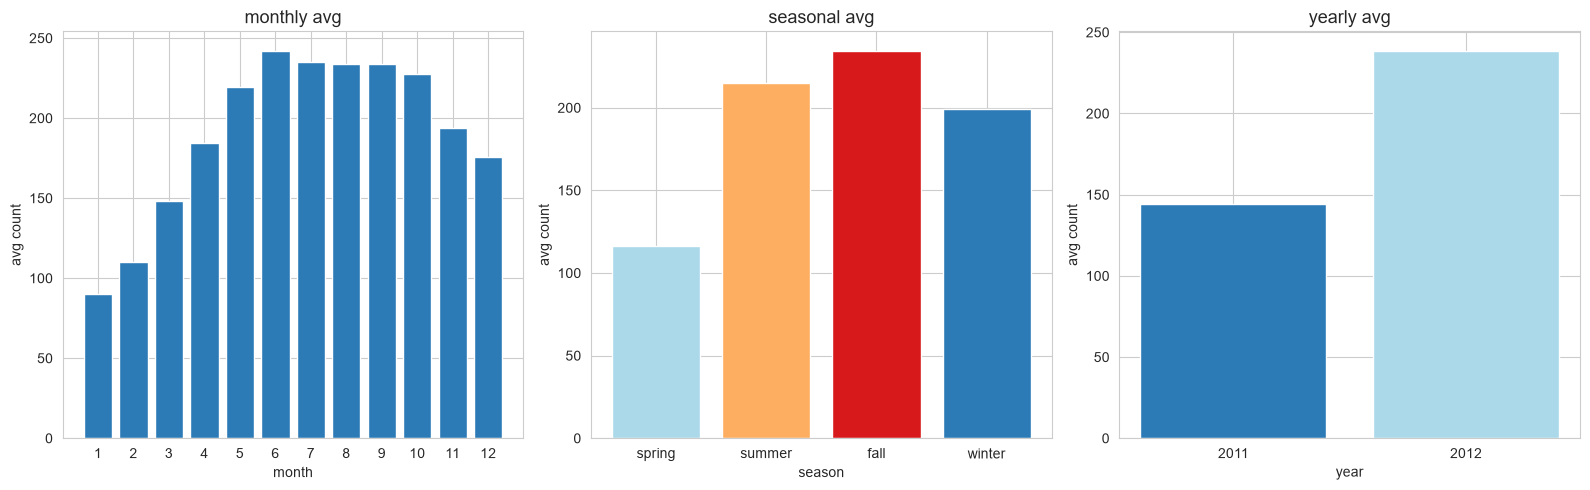

peak month: 6 (avg 242)
lowest month: 1 (avg 90)
2011->2012 growth: 65%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 月份
monthly = train.groupby("month")["count"].agg(["mean", "std"])
axes[0].bar(monthly.index, monthly["mean"], color="#2c7bb6", edgecolor="white")
axes[0].set_xlabel("month")
axes[0].set_ylabel("avg count")
axes[0].set_title("monthly avg", fontsize=13)
axes[0].set_xticks(range(1, 13))

# 季节
sl = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
sd = train.groupby("season")["count"].mean()
colors = ["#abd9e9", "#fdae61", "#d7191c", "#2c7bb6"]
axes[1].bar([sl[s] for s in sd.index], sd.values, color=colors, edgecolor="white")
axes[1].set_xlabel("season")
axes[1].set_ylabel("avg count")
axes[1].set_title("seasonal avg", fontsize=13)

# 年份
yl = train.groupby("year")["count"].mean()
axes[2].bar(yl.index.astype(str), yl.values, color=["#2c7bb6", "#abd9e9"], edgecolor="white")
axes[2].set_xlabel("year")
axes[2].set_ylabel("avg count")
axes[2].set_title("yearly avg", fontsize=13)

plt.tight_layout()
plt.savefig("output/figures/seasonal-patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print(f'peak month: {monthly["mean"].idxmax():.0f} (avg {monthly["mean"].max():.0f})')
print(f'lowest month: {monthly["mean"].idxmin():.0f} (avg {monthly["mean"].min():.0f})')
print(f'2011->2012 growth: {(yl[2012] / yl[2011] - 1) * 100:.0f}%')

季节和年份的趋势很清晰：夏天和秋天是骑行旺季，冬天最低。2012 年比 2011 年整体增长了约 70%——共享单车在快速普及。

测试集的日期覆盖了 `train` 没有的时段（每月 20 日之后），所以年份趋势和月内日期位置都值得作为特征。

---

### 2.5 天气的影响


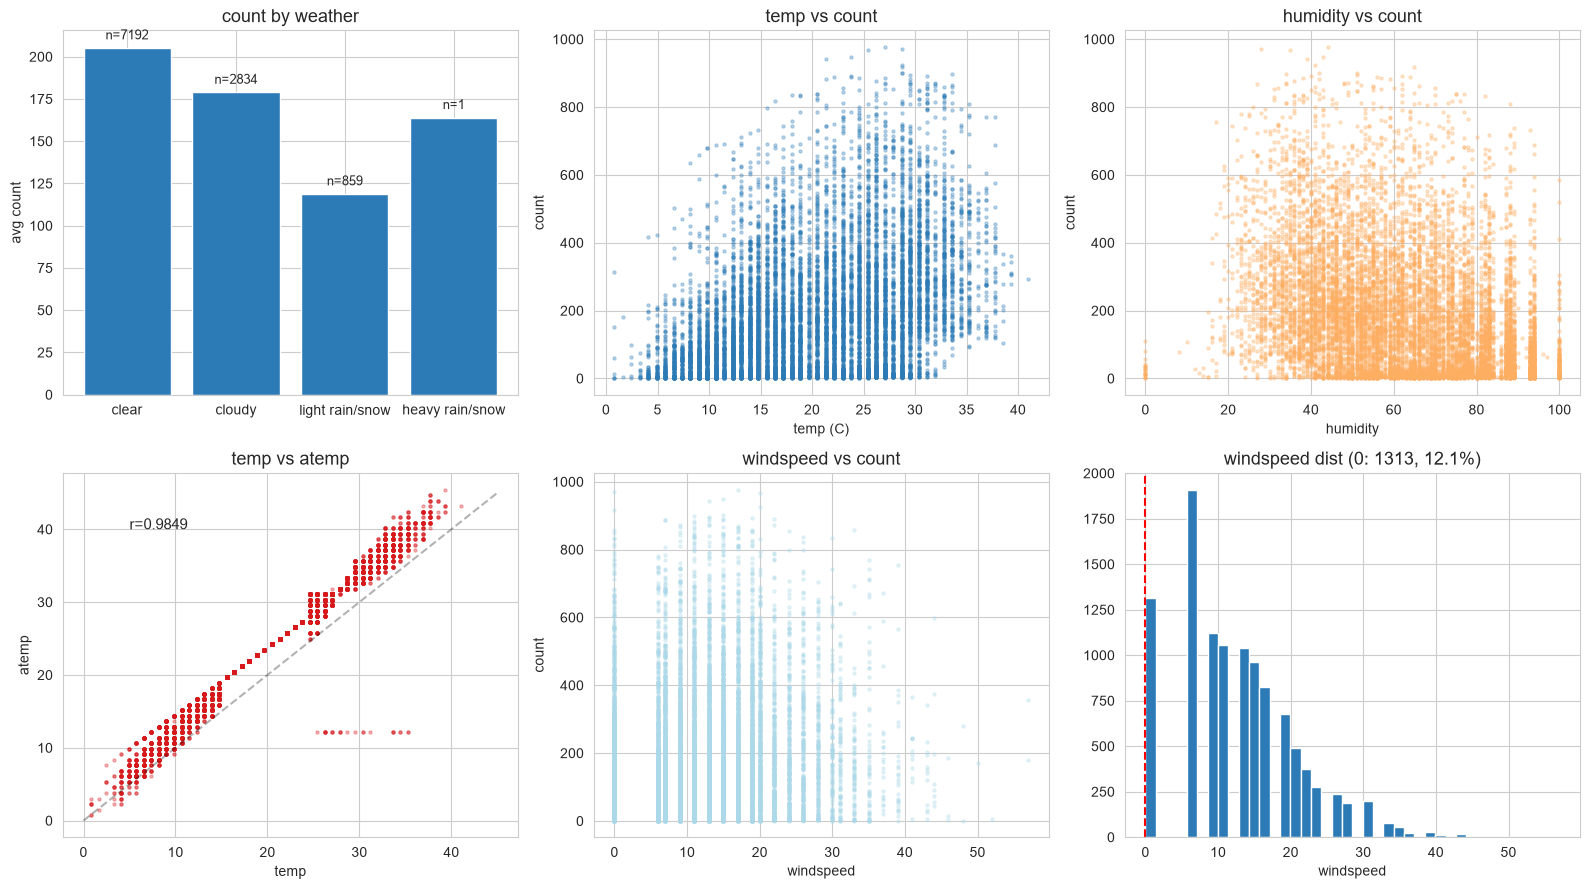

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# weather
wl = {1: "clear", 2: "cloudy", 3: "light rain/snow", 4: "heavy rain/snow"}
wd2 = train.groupby("weather")["count"].agg(["mean", "count"])
axes[0, 0].bar([wl.get(w, str(w)) for w in wd2.index], wd2["mean"], color="#2c7bb6", edgecolor="white")
axes[0, 0].set_title("count by weather", fontsize=13)
axes[0, 0].set_ylabel("avg count")
for i, (m, c) in enumerate(zip(wd2["mean"], wd2["count"])):
    axes[0, 0].text(i, m + 5, f"n={c}", ha="center", fontsize=9)

# temp vs count
axes[0, 1].scatter(train["temp"], train["count"], alpha=0.3, s=5, color="#2c7bb6")
axes[0, 1].set_xlabel("temp (C)")
axes[0, 1].set_ylabel("count")
axes[0, 1].set_title("temp vs count", fontsize=13)

# humidity vs count
axes[0, 2].scatter(train["humidity"], train["count"], alpha=0.3, s=5, color="#fdae61")
axes[0, 2].set_xlabel("humidity")
axes[0, 2].set_ylabel("count")
axes[0, 2].set_title("humidity vs count", fontsize=13)

# temp vs atemp
axes[1, 0].scatter(train["temp"], train["atemp"], alpha=0.3, s=5, color="#d7191c")
axes[1, 0].plot([0, 45], [0, 45], "k--", alpha=0.3)
axes[1, 0].set_xlabel("temp")
axes[1, 0].set_ylabel("atemp")
axes[1, 0].set_title("temp vs atemp", fontsize=13)
r = train["temp"].corr(train["atemp"])
axes[1, 0].text(5, 40, f"r={r:.4f}", fontsize=11)

# windspeed vs count
axes[1, 1].scatter(train["windspeed"], train["count"], alpha=0.3, s=5, color="#abd9e9")
axes[1, 1].set_xlabel("windspeed")
axes[1, 1].set_ylabel("count")
axes[1, 1].set_title("windspeed vs count", fontsize=13)

# 风速=0
zw = (train["windspeed"] == 0).sum()
axes[1, 2].hist(train["windspeed"], bins=40, edgecolor="white", color="#2c7bb6")
axes[1, 2].axvline(0, color="red", linestyle="--")
axes[1, 2].set_xlabel("windspeed")
axes[1, 2].set_title(f"windspeed dist (0: {zw}, {zw/len(train)*100:.1f}%)", fontsize=13)

plt.tight_layout()
plt.savefig("output/figures/weather-analysis.png", dpi=150, bbox_inches="tight")
plt.show()

天气角度的发现：

1. **极端天气（weather=4）只有 1 条记录** — 模型基本学不到这个类别的信号
2. **温度和租车量正相关，但有天花板效应** — 太热（>35°C）后租车量反而下降
3. **temp 和 atemp 几乎完全共线（r≈0.99）** — 建模时保留一个即可
4. **高湿度时段租车量偏低**，但关系较弱
5. **风速为零的比例约 13%** — 传感器故障的可能性很大，需要在清洗阶段处理

---

### 2.6 casual vs registered 的行为差异

这是决定后续建模策略（分头预测）的关键依据。

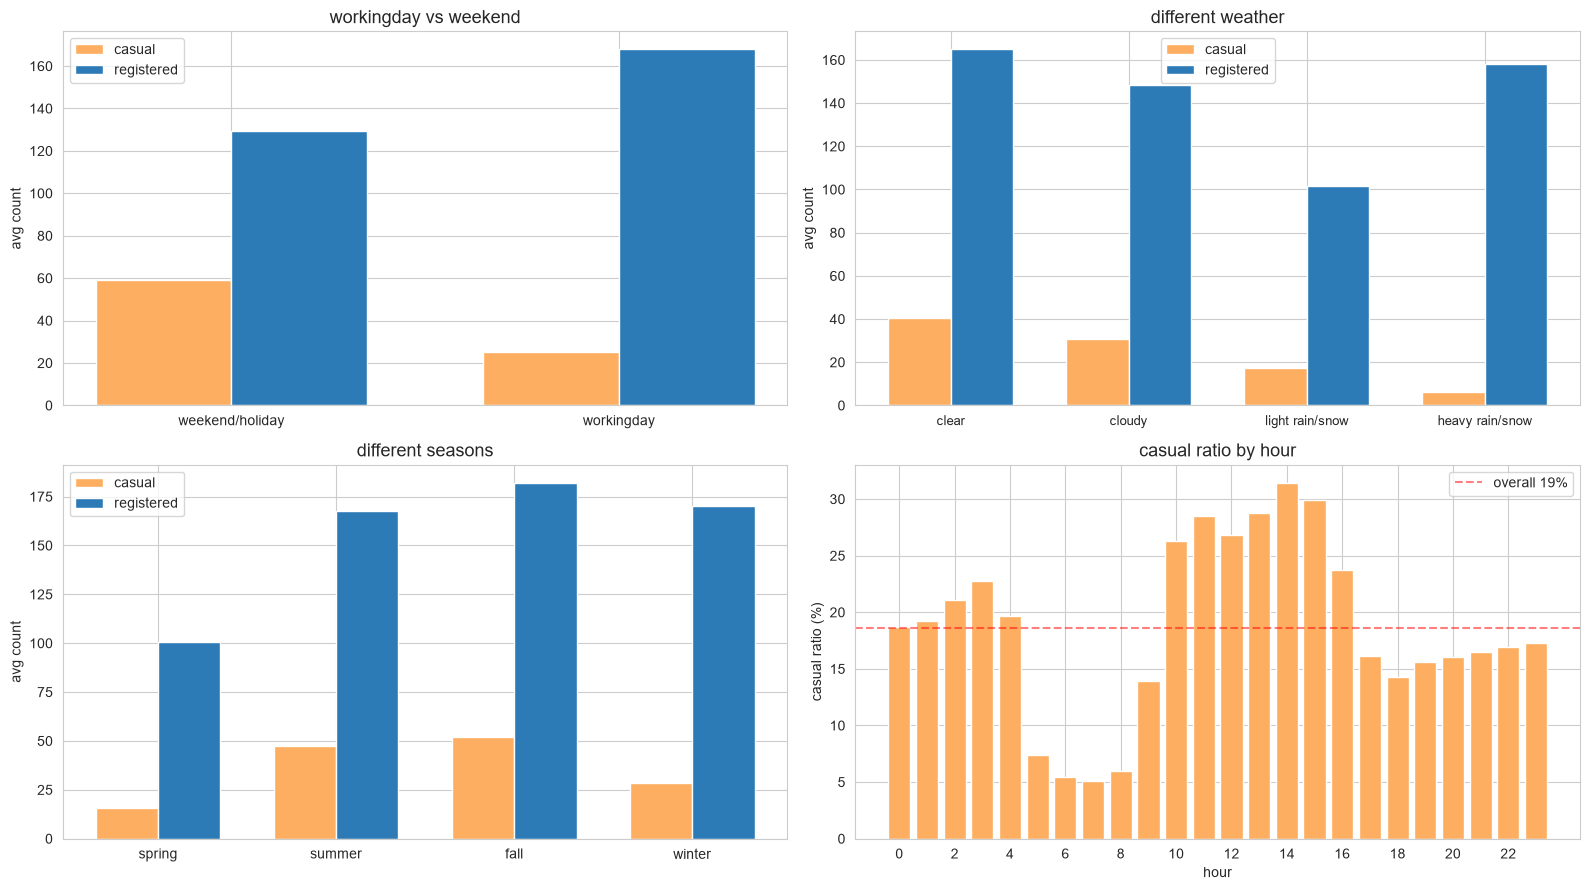

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
w = 0.35

# 工作日 vs 周末
wc = train.groupby("workingday")["casual"].mean()
wr = train.groupby("workingday")["registered"].mean()
x = np.array([0, 1])
axes[0, 0].bar(x - w/2, wc, w, color="#fdae61", label="casual")
axes[0, 0].bar(x + w/2, wr, w, color="#2c7bb6", label="registered")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(["weekend/holiday", "workingday"])
axes[0, 0].set_ylabel("avg count")
axes[0, 0].set_title("workingday vs weekend", fontsize=13)
axes[0, 0].legend()

# 天气
wdc = train.groupby("weather")["casual"].mean()
wdr = train.groupby("weather")["registered"].mean()
x_w = np.arange(len(wdc))
axes[0, 1].bar(x_w - w/2, wdc, w, color="#fdae61", label="casual")
axes[0, 1].bar(x_w + w/2, wdr, w, color="#2c7bb6", label="registered")
axes[0, 1].set_xticks(x_w)
axes[0, 1].set_xticklabels([wl[w] for w in wdc.index], fontsize=9)
axes[0, 1].set_ylabel("avg count")
axes[0, 1].set_title("different weather", fontsize=13)
axes[0, 1].legend()

# 季节
sc = train.groupby("season")["casual"].mean()
sr = train.groupby("season")["registered"].mean()
x_s = np.arange(len(sc))
axes[1, 0].bar(x_s - w/2, sc, w, color="#fdae61", label="casual")
axes[1, 0].bar(x_s + w/2, sr, w, color="#2c7bb6", label="registered")
axes[1, 0].set_xticks(x_s)
axes[1, 0].set_xticklabels([sl[s] for s in sc.index])
axes[1, 0].set_ylabel("avg count")
axes[1, 0].set_title("different seasons", fontsize=13)
axes[1, 0].legend()

# 每小时 casual 占比
cr = train.groupby("hour")["casual"].sum() / train.groupby("hour")["count"].sum()
axes[1, 1].bar(hours, cr.values * 100, color="#fdae61", edgecolor="white")
axes[1, 1].axhline(y=cr.mean() * 100, color="red", linestyle="--", alpha=0.5, label=f"overall {cr.mean()*100:.0f}%")
axes[1, 1].set_xlabel("hour")
axes[1, 1].set_ylabel("casual ratio (%)")
axes[1, 1].set_title("casual ratio by hour", fontsize=13)
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("output/figures/casual-vs-registered.png", dpi=150, bbox_inches="tight")
plt.show()

casual 和 registered 的用户画像完全不同：

| 维度 | casual | registered |
|------|--------|------------|
| 工作日 vs 周末 | 周末高 | 工作日高 |
| 小时分布 | 中午到傍晚 | 早晚双峰 |
| 天气敏感度 | 极高（坏天骤降） | 中（通勤刚需） |
| 季节偏好 | 夏秋高，冬春低 | 全年相对平稳 |

**结论：两者由不同的因素驱动，分头建模有理论支撑。**

---

### 2.7 EDA 小结

通过这几轮观察，关键发现整理如下：

1. **hour 是最强信号** — 不同小时的租车量差异可达 10 倍以上
2. **hour 的效果取决于 workingday** — 同样的早 8 点，工作日 vs 周末完全不同
3. **temp 和 atemp 只保留一个** — 共线性太高（r≈0.99）
4. **windspeed=0 不自然** — 高达 13%，需要处理
5. **casual 和 registered 行为模式分化明显** — 分头建模是合理选择
6. **2012 年比 2011 年增长了约 70%** — year 是必要的特征

接下来：构造特征、处理异常值、建立 baseline。

---

## 第 3 章 · 特征工程


### 3.1 特征工程策略

基于 EDA 的发现，设计以下特征：

| 类别 | 特征 | 构造方式 |
|------|------|----------|
| 时间分解 | `hour`, `weekday`, `month`, `year`, `day` | 从 datetime 直接提取 |
| 循环编码 🆕 | `hour_sin/cos`, `month_sin/cos`, `weekday_sin/cos` | sin/cos 变换，让模型理解 23 点和 0 点的距离只有 1 小时 |
| 时段标记 | `day_period` | 凌晨(0-5) / 上午(6-11) / 下午(12-17) / 晚上(18-23) |
| 高峰标记 | `is_rush_morning`, `is_rush_evening` | 工作日 7-9 / 17-19 |
| 周末标记 | `is_weekend` | weekday >= 5 |
| 交互特征 | `hour×workingday`, `hour×season` | 捕获时间维度的条件效应 |
| 天气交互 | `temp×humidity`, `workingday×weather` 🆕 | 体感舒适度代理 + 坏天气对工作日/周末影响不同 |

**v2 关键改动**：
- `hour`/`month`/`weekday` 做了 sin/cos 循环编码，这是 v1→v2 最重要的改进——解决了"23 点离 0 点很远"的数值错觉
- `temp` → `atemp`：体感温度对骑行决策的影响比实际温度更直接
- `weather=4`（1 条样本）并入 `weather=3`，去噪
- 新增 `workingday × weather` 交互

**不引入滞后特征**：测试集没有历史 count，迭代预测会放大误差，收益/成本比不划算。

In [ ]:
# === 合并数据，统一构造特征 ===
all_data = pd.concat([train.drop(['casual', 'registered', 'count'], axis=1), test],
                     axis=0, sort=False, ignore_index=True)

# === 时间分解 ===
all_data['hour'] = all_data['datetime'].dt.hour
all_data['weekday'] = all_data['datetime'].dt.dayofweek  # 0=Mon, 6=Sun
all_data['month'] = all_data['datetime'].dt.month
all_data['year'] = all_data['datetime'].dt.year
all_data['day'] = all_data['datetime'].dt.day

# === v2: 循环编码（解决 23→0 的数值断层） ===
all_data['hour_sin'] = np.sin(2 * np.pi * all_data['hour'] / 24)
all_data['hour_cos'] = np.cos(2 * np.pi * all_data['hour'] / 24)
all_data['month_sin'] = np.sin(2 * np.pi * all_data['month'] / 12)
all_data['month_cos'] = np.cos(2 * np.pi * all_data['month'] / 12)
all_data['weekday_sin'] = np.sin(2 * np.pi * all_data['weekday'] / 7)
all_data['weekday_cos'] = np.cos(2 * np.pi * all_data['weekday'] / 7)

# === 周末标记 ===
all_data['is_weekend'] = (all_data['weekday'] >= 5).astype(int)

# === 时段分类 ===
def classify_period(h):
    if h <= 5: return 0   # 凌晨
    elif h <= 11: return 1 # 上午
    elif h <= 17: return 2 # 下午
    else: return 3          # 晚上
all_data['day_period'] = all_data['hour'].apply(classify_period)

# === 高峰时段标记 ===
all_data['is_rush_morning'] = ((all_data['hour'] >= 7) & (all_data['hour'] <= 9) &
                                 (all_data['workingday'] == 1)).astype(int)
all_data['is_rush_evening'] = ((all_data['hour'] >= 17) & (all_data['hour'] <= 19) &
                                (all_data['workingday'] == 1)).astype(int)

# === 交互特征 ===
all_data['hour_x_workingday'] = all_data['hour'] * all_data['workingday']
all_data['hour_x_season'] = all_data['hour'] * all_data['season']

# v2: 用 atemp 替代 temp（体感温度更直接影响骑行决策）
all_data['atemp_x_humidity'] = all_data['atemp'] * all_data['humidity']

# v2: 坏天气对工作日/周末影响不同
all_data['workingday_x_weather'] = all_data['workingday'] * all_data['weather']

# === 验证 ===
print(f'特征维度: {all_data.shape[1]}')
all_data.head(3)

### 3.2 特征选择

把构造好的特征整理成最终的特征列表。排除原始 datetime 和冗余字段。

In [ ]:
# === 最终特征列表（v2） ===
features = [
    'season', 'holiday', 'workingday', 'weather',
    'atemp', 'humidity', 'windspeed',              # v2: atemp 替代 temp
    'hour', 'weekday', 'month', 'year', 'day',     # 时间分解
    'hour_sin', 'hour_cos',                         # v2: 循环编码
    'month_sin', 'month_cos',
    'weekday_sin', 'weekday_cos',
    'is_weekend', 'day_period',                     # 时段标记
    'is_rush_morning', 'is_rush_evening',           # 高峰标记
    'hour_x_workingday', 'hour_x_season',           # 时间交互
    'atemp_x_humidity',                             # v2: 天气交互（atemp 版）
    'workingday_x_weather',                         # v2: 坏天气×工作日交互
]

print(f'特征数量: {len(features)}')
print(features)

---

## 第 4 章 · 数据清洗


### 4.1 windspeed=0 处理

13% 的风速数据为 0，物理上不太可能出现 —— DC 不是全年无风的地方。更可能是传感器故障。

处理策略：按天气条件分组，用各组中位数填充风速为 0 的记录。这样比全局中位数更精细。

In [13]:
# === 处理 windspeed=0 ===
zero_wind_mask = all_data['windspeed'] == 0
print(f'windspeed=0 的记录: {zero_wind_mask.sum()} ({zero_wind_mask.sum()/len(all_data)*100:.1f}%)')

# 按 weather 条件分组填充中位数
for weather_type in all_data['weather'].unique():
    mask = (all_data['weather'] == weather_type) & (all_data['windspeed'] == 0)
    median_wind = all_data.loc[(all_data['weather'] == weather_type) & (all_data['windspeed'] > 0), 'windspeed'].median()
    if pd.notna(median_wind):
        all_data.loc[mask, 'windspeed'] = median_wind
        count = mask.sum()
        if count > 0:
            print(f'  weather={weather_type}: 填充 {count} 条 → 中位数 {median_wind:.2f}')

print(f'处理后 windspeed=0: {(all_data["windspeed"] == 0).sum()} 条')

windspeed=0 的记录: 2180 (12.5%)
  weather=1: 填充 1493 条 → 中位数 13.00
  weather=2: 填充 570 条 → 中位数 13.00
  weather=3: 填充 117 条 → 中位数 15.00
处理后 windspeed=0: 0 条


### 4.2 humidity 异常值

湿度理论范围是 0-100。检查是否有超出范围或明显不合理的数据。

In [14]:
# === humidity 检查 ===
print(f'humidity 范围: {all_data["humidity"].min():.0f} ~ {all_data["humidity"].max():.0f}')
print(f'humidity=0: {(all_data["humidity"] == 0).sum()} 条')
print(f'humidity=100: {(all_data["humidity"] == 100).sum()} 条')
print(f'humidity < 10: {(all_data["humidity"] < 10).sum()} 条')

# humidity 为 0 的极端情况 → 用 weather 分组中位数填充
zero_humid = all_data['humidity'] == 0
print(f'\nhumidity=0 的 weather 分布:')
print(all_data.loc[zero_humid, "weather"].value_counts())

humidity 范围: 0 ~ 100
humidity=0: 22 条
humidity=100: 270 条
humidity < 10: 23 条

humidity=0 的 weather 分布:
weather
3    20
2     2
Name: count, dtype: int64


In [15]:
# === humidity=0 填充 ===
for weather_type in all_data['weather'].unique():
    mask = (all_data['weather'] == weather_type) & (all_data['humidity'] == 0)
    median_h = all_data.loc[(all_data['weather'] == weather_type) & (all_data['humidity'] > 0), 'humidity'].median()
    if pd.notna(median_h):
        all_data.loc[mask, 'humidity'] = median_h

print(f'处理后 humidity=0: {(all_data["humidity"] == 0).sum()} 条')

处理后 humidity=0: 0 条


In [ ]:
# === v2: weather=4 并入 weather=3（只有 1 条样本，纯噪声） ===
weather4_count = (all_data['weather'] == 4).sum()
print(f'weather=4 原始: {weather4_count} 条')
all_data.loc[all_data['weather'] == 4, 'weather'] = 3
print(f'处理后 weather=4: {(all_data["weather"] == 4).sum()} 条')
print(f'处理后 weather 分布:\n{all_data["weather"].value_counts().sort_index()}')

### 4.3 temp 和 atemp 共线性 + weather=4 去噪

EDA 阶段确认了 temp 和 atemp 的相关系数 ≈ 0.99。v2 改用 `atemp`（体感温度），它对骑行决策的影响比实际温度更直接——人感受的是"外面感觉有多热/冷"，而不是温度计的数字。

另外 `weather=4` 只有 1 条样本，模型完全学不到信号。把它并入 `weather=3`（小雨/雪），减少噪声维度。

### 4.4 数据分割

特征构造和清洗完成后，重新切分训练集和测试集。

In [16]:
# === 重新切分 ===
train_len = len(train)
train_processed = all_data[:train_len].copy()
test_processed = all_data[train_len:].copy()

# 目标变量（log1p 变换）
y_count = np.log1p(train['count'].values)
y_casual = np.log1p(train['casual'].values)
y_registered = np.log1p(train['registered'].values)

# 提取特征矩阵
X = train_processed[features].values
X_test = test_processed[features].values

print(f'X: {X.shape}, y_count: {y_count.shape}')
print(f'X_test: {X_test.shape}')
print(f'特征完整性: null={np.isnan(X).sum()}, inf={np.isinf(X).sum()}')

X: (10886, 19), y_count: (10886,)
X_test: (6493, 19)
特征完整性: null=0, inf=0


### 4.5 清洗小结

| 问题 | 处理方式 |
|------|----------|
| windspeed=0（13%） | 按 weather 分组中位数填充 |
| humidity=0 | 按 weather 分组中位数填充 |
| temp/atemp 共线（r≈0.99） | v2: 改用 atemp（体感温度），移除 temp |
| weather=4（1 条） | v2: 并入 weather=3 |

接下来进入建模阶段。

---

## 第 5 章 · Baseline 建模


### 5.1 建模准备

回顾目前的准备状态：
- 特征矩阵 X (26 维) 已构造完成（v2: 循环编码 + atemp + 新交互）
- y_count / y_casual / y_registered 已 log1p 变换
- 训练集 / 测试集已划分

评估统一用 **RMSLE**，交叉验证用 **TimeSeriesSplit**（按时间顺序划分，不用随机打乱）。

In [17]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# === RMSLE 评估函数（输入已在 log1p 空间，先还原再算 RMSLE） ===
def rmsle_metric(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# === 时间序列 CV ===
tscv = TimeSeriesSplit(n_splits=5)
print("TimeSeriesSplit(5) 已就绪")
print(f"训练集大小: {len(X)}, 测试集大小: {len(X_test)}")

TimeSeriesSplit(5) 已就绪
训练集大小: 10886, 测试集大小: 6493


### 5.2 Baseline 模型（直接预测 count）

先用 4 个基础模型直接预测 `log1p(count)`，不做调参，仅看 baseline 水平。

In [18]:
# === 定义基础模型（默认参数） ===
base_models = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1),
}

# === 评估每个模型（预测 count） ===
print('=== Baseline: 直接预测 count ===\n')
results_count = {}
for name, model in base_models.items():
    scores = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_count[train_idx], y_count[val_idx]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        score = rmsle_metric(y_val, y_pred)
        scores.append(score)
        print(f'  {name} Fold{fold+1}: RMSLE={score:.4f}')
    
    results_count[name] = {"mean": np.mean(scores), "std": np.std(scores)}
    print(f'  → {name} Avg RMSLE: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})\n')

# === 汇总 ===
print('=== Direct predict summary ===')
for name, r in sorted(results_count.items(), key=lambda x: x[1]["mean"]):
    print(f'  {name:15s}  RMSLE={r["mean"]:.4f} (+/- {r["std"]:.4f})')

=== Baseline: 直接预测 count ===

  Ridge Fold1: RMSLE=0.8615
  Ridge Fold2: RMSLE=1.0141
  Ridge Fold3: RMSLE=0.8909
  Ridge Fold4: RMSLE=0.8231
  Ridge Fold5: RMSLE=0.7896
  → Ridge Avg RMSLE: 0.8758 (+/- 0.0772)

  RandomForest Fold1: RMSLE=0.6286
  RandomForest Fold2: RMSLE=0.4765
  RandomForest Fold3: RMSLE=0.7599
  RandomForest Fold4: RMSLE=0.3644
  RandomForest Fold5: RMSLE=0.4103
  → RandomForest Avg RMSLE: 0.5280 (+/- 0.1464)

  XGBoost Fold1: RMSLE=0.6861
  XGBoost Fold2: RMSLE=0.3997
  XGBoost Fold3: RMSLE=0.6600
  XGBoost Fold4: RMSLE=0.3215
  XGBoost Fold5: RMSLE=0.3515
  → XGBoost Avg RMSLE: 0.4838 (+/- 0.1568)

  LightGBM Fold1: RMSLE=0.4249
  LightGBM Fold2: RMSLE=0.3735
  LightGBM Fold3: RMSLE=0.5232
  LightGBM Fold4: RMSLE=0.3093
  LightGBM Fold5: RMSLE=0.3413
  → LightGBM Avg RMSLE: 0.3944 (+/- 0.0749)

=== Direct predict summary ===
  LightGBM         RMSLE=0.3944 (+/- 0.0749)
  XGBoost          RMSLE=0.4838 (+/- 0.1568)
  RandomForest     RMSLE=0.5280 (+/- 0.1464)
  Ri

### 5.3 分头预测策略

EDA 阶段发现 casual 和 registered 的行为模式差异很大。尝试分别建模：

1. Model_A 预测 `log1p(casual)`
2. Model_B 预测 `log1p(registered)`
3. 最终预测 = `expm1(pred_casual) + expm1(pred_registered)`

这个策略的理论基础：两类用户几乎不受相同的因素驱动，分开建模让每个模型专注学自己该学的东西。

In [19]:
# === 分头预测：每个模型分别预测 casual 和 registered ===
print('=== Split predict: casual + registered ===\n')
results_split = {}

for name, model_cls in [
    ('Ridge', Ridge(alpha=1.0, random_state=42)),
    ('RandomForest', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ('XGBoost', XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0)),
    ('LightGBM', LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1)),
]:
    scores = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X[train_idx], X[val_idx]
        
        # 预测 casual
        m_c = model_cls.__class__(**model_cls.get_params())
        m_c.fit(X_tr, y_casual[train_idx])
        pred_casual_log = m_c.predict(X_val)
        
        # 预测 registered
        m_r = model_cls.__class__(**model_cls.get_params())
        m_r.fit(X_tr, y_registered[train_idx])
        pred_registered_log = m_r.predict(X_val)
        
        # 合并
        pred_total = np.expm1(pred_casual_log) + np.expm1(pred_registered_log)
        y_true_total = np.expm1(y_count[val_idx])
        score = rmsle(y_true_total, pred_total)
        scores.append(score)
        print(f'  {name} Fold{fold+1}: RMSLE={score:.4f}')
    
    results_split[name] = {"mean": np.mean(scores), "std": np.std(scores)}
    print(f'  → {name} Avg RMSLE: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})\n')

# === 对比 ===
print('=== Direct vs Split comparison ===')
print(f'{"Model":15s}  {"Direct":>10s}  {"Split":>10s}  {"Improvement":>12s}')
print('-' * 52)
for name in results_count:
    d = results_count[name]["mean"]
    s = results_split[name]["mean"]
    imp = (d - s) / d * 100
    print(f'{name:15s}  {d:10.4f}  {s:10.4f}  {imp:>+11.1f}%')

=== Split predict: casual + registered ===

  Ridge Fold1: RMSLE=0.9424
  Ridge Fold2: RMSLE=1.0335
  Ridge Fold3: RMSLE=0.8889
  Ridge Fold4: RMSLE=0.8151
  Ridge Fold5: RMSLE=0.7898
  → Ridge Avg RMSLE: 0.8939 (+/- 0.0882)

  RandomForest Fold1: RMSLE=0.5919
  RandomForest Fold2: RMSLE=0.4587
  RandomForest Fold3: RMSLE=0.7475
  RandomForest Fold4: RMSLE=0.3574
  RandomForest Fold5: RMSLE=0.3936
  → RandomForest Avg RMSLE: 0.5098 (+/- 0.1432)

  XGBoost Fold1: RMSLE=0.6046
  XGBoost Fold2: RMSLE=0.3790
  XGBoost Fold3: RMSLE=0.6502
  XGBoost Fold4: RMSLE=0.3023
  XGBoost Fold5: RMSLE=0.3512
  → XGBoost Avg RMSLE: 0.4574 (+/- 0.1416)

  LightGBM Fold1: RMSLE=0.4222
  LightGBM Fold2: RMSLE=0.3787
  LightGBM Fold3: RMSLE=0.5911
  LightGBM Fold4: RMSLE=0.2953
  LightGBM Fold5: RMSLE=0.3444
  → LightGBM Avg RMSLE: 0.4063 (+/- 0.1013)

=== Direct vs Split comparison ===
Model                Direct       Split   Improvement
----------------------------------------------------
Ridge         

### 5.4 Baseline 总结

对比实验的结论决定了后续方向：

1. **最佳单一模型是哪个？** — 决定了调参的主力
2. **分头预测是否优于直接预测？** — 如果是，后续调参和集成统一用 split 策略
3. **树模型（XGB/LGB）vs 线性模型（Ridge）** — 决定了集成的互补性

接下来：对表现最好的模型做深度调参。

---

## 第 6 章 · 深度调参


### 6.1 调参策略

用 `RandomizedSearchCV` 替代 GridSearchCV：参数量大时，随机搜索能更快找到近似最优。

- **CV**：TimeSeriesSplit(5)，跟 baseline 一致
- **Scoring**：neg_root_mean_squared_error（对应 log 空间的 RMSE）
- **搜索次数**：XGBoost/LightGBM → 100 组（v2: 50→100），RandomForest → 50 组（v2: 30→50）
- **重点模型**：XGBoost 和 LightGBM（梯度提升树通常最优），RandomForest 做轻量搜索

所有调参都在 **分头预测** 框架下进行 — 即分别对 casual 和 registered 做搜索。

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("RandomizedSearchCV 已导入")

RandomizedSearchCV 已导入


### 6.2 XGBoost 调参


In [ ]:
# === XGBoost 超参空间 ===
xgb_params = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': uniform(0, 3),
    'reg_lambda': uniform(0.5, 5),
    'min_child_weight': randint(1, 15),
}

xgb_search_casual = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params, n_iter=100, cv=tscv,  # v2: 50→100
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search_casual.fit(X, y_casual)
print(f'XGB casual best: RMSLE={-xgb_search_casual.best_score_:.4f}')
print(f'  params: {xgb_search_casual.best_params_}')

xgb_search_registered = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params, n_iter=100, cv=tscv,  # v2: 50→100
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search_registered.fit(X, y_registered)
print(f'\nXGB registered best: RMSLE={-xgb_search_registered.best_score_:.4f}')
print(f'  params: {xgb_search_registered.best_params_}')

### 6.3 LightGBM 调参


In [ ]:
# === LightGBM 超参空间 ===
lgb_params = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(3, 15),
    'num_leaves': randint(20, 150),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': uniform(0, 3),
    'reg_lambda': uniform(0.5, 5),
    'min_child_samples': randint(5, 60),
}

lgb_search_casual = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    lgb_params, n_iter=100, cv=tscv,  # v2: 50→100
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0
)
lgb_search_casual.fit(X, y_casual)
print(f'LGB casual best: RMSLE={-lgb_search_casual.best_score_:.4f}')
print(f'  params: {lgb_search_casual.best_params_}')

lgb_search_registered = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    lgb_params, n_iter=100, cv=tscv,  # v2: 50→100
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0
)
lgb_search_registered.fit(X, y_registered)
print(f'\nLGB registered best: RMSLE={-lgb_search_registered.best_score_:.4f}')
print(f'  params: {lgb_search_registered.best_params_}')

### 6.4 RandomForest 调参（轻量）


In [ ]:
# === RF 超参空间（轻量搜索 50 组，v2: 30→50） ===
rf_params = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 25),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 15),
    'max_features': ['sqrt', 'log2', None],
}

rf_search_casual = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, n_iter=50, cv=tscv,  # v2: 30→50
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search_casual.fit(X, y_casual)
print(f'RF casual best: RMSLE={-rf_search_casual.best_score_:.4f}')
print(f'  params: {rf_search_casual.best_params_}')

rf_search_registered = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, n_iter=50, cv=tscv,  # v2: 30→50
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search_registered.fit(X, y_registered)
print(f'\nRF registered best: RMSLE={-rf_search_registered.best_score_:.4f}')
print(f'  params: {rf_search_registered.best_params_}')

### 6.5 调参总结

对比调参前后，确认调参的收益。同时记录最优参数，为集成做准备。

In [ ]:
# === 调参前后对比（分头预测框架下） ===
print('=== Tuning Summary (split-predict framework) ===\n')

import copy
# 构建调参后的最优模型（深拷贝，避免后续 fit 污染 best_estimator_）
best_models = {
    'XGBoost': (
        copy.deepcopy(xgb_search_casual.best_estimator_),
        copy.deepcopy(xgb_search_registered.best_estimator_)
    ),
    'LightGBM': (
        copy.deepcopy(lgb_search_casual.best_estimator_),
        copy.deepcopy(lgb_search_registered.best_estimator_)
    ),
    'RandomForest': (
        copy.deepcopy(rf_search_casual.best_estimator_),
        copy.deepcopy(rf_search_registered.best_estimator_)
    ),
}

# 保存调参后模型的 CV RMSLE，供最终对比使用
tuned_split_results = {}

print(f'{"Model":15s} {"Baseline":>10s} {"Tuned":>10s} {"Improvement":>12s}')
print('-' * 52)
baseline_ref = {
    'XGBoost': results_split.get('XGBoost', {}).get('mean', 0),
    'LightGBM': results_split.get('LightGBM', {}).get('mean', 0),
    'RandomForest': results_split.get('RandomForest', {}).get('mean', 0),
}

for name in best_models:
    # 在完整训练集上评估调参后模型
    m_c, m_r = best_models[name]
    tuned_scores = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X[train_idx], X[val_idx]
        m_c.fit(X_tr, y_casual[train_idx])
        m_r.fit(X_tr, y_registered[train_idx])
        pred_total = np.expm1(m_c.predict(X_val)) + np.expm1(m_r.predict(X_val))
        score = rmsle(np.expm1(y_count[val_idx]), pred_total)
        tuned_scores.append(score)
    tuned_mean = np.mean(tuned_scores)
    tuned_split_results[name] = tuned_mean  # ← v2: 保存供最终对比
    base = baseline_ref.get(name, 0)
    imp = (base - tuned_mean) / base * 100 if base > 0 else 0
    print(f'{name:15s}  {base:10.4f}  {tuned_mean:10.4f}  {imp:>+11.1f}%')

---

## 第 7 章 · 集成与 Stacking


### 7.1 集成策略

用 `StackingRegressor` 将调参后的最优模型做两层集成：

- **Base estimators**：XGBoost + LightGBM + RandomForest（调参后最优）
- **Meta learner**：Ridge Regression
- **CV**：TimeSeriesSplit(5)，保持一致性

对 casual 和 registered 各建一个 Stacking，然后合并预测。

In [25]:
from sklearn.ensemble import StackingRegressor

# === 为 casual 构建 Stacking ===
base_estimators_casual = [
    ('xgb', xgb_search_casual.best_estimator_),
    ('lgb', lgb_search_casual.best_estimator_),
    ('rf', rf_search_casual.best_estimator_),
]

stack_casual = StackingRegressor(
    estimators=base_estimators_casual,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=5, n_jobs=-1
)

# === 为 registered 构建 Stacking ===
base_estimators_registered = [
    ('xgb', xgb_search_registered.best_estimator_),
    ('lgb', lgb_search_registered.best_estimator_),
    ('rf', rf_search_registered.best_estimator_),
]

stack_registered = StackingRegressor(
    estimators=base_estimators_registered,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=5, n_jobs=-1
)

print("StackingRegressor 已构建（casual + registered）")

StackingRegressor 已构建（casual + registered）


### 7.2 最终对比实验

三种策略放在一起比，确认最优方案：

1. **Direct** — 最优单一模型直接预测 count
2. **Split** — 最优单一模型分头预测 casual + registered
3. **Stacking** — 分头预测 + Stacking 集成

用 TimeSeriesSplit 跑完 5-fold，比较 RMSLE 均值。

In [26]:
# === 策略 3: Stacking 分头预测 ===
print('=== Strategy 3: Stacking + Split predict ===\n')
stack_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X[train_idx], X[val_idx]
    
    # casual stacking
    stack_casual.fit(X_tr, y_casual[train_idx])
    pred_casual_log = stack_casual.predict(X_val)
    
    # registered stacking
    stack_registered.fit(X_tr, y_registered[train_idx])
    pred_registered_log = stack_registered.predict(X_val)
    
    # 合并
    pred_total = np.expm1(pred_casual_log) + np.expm1(pred_registered_log)
    y_true_total = np.expm1(y_count[val_idx])
    score = rmsle(y_true_total, pred_total)
    stack_scores.append(score)
    print(f'  Fold{fold+1}: RMSLE={score:.4f}')

print(f'\nStacking Avg RMSLE: {np.mean(stack_scores):.4f} (+/- {np.std(stack_scores):.4f})')

=== Strategy 3: Stacking + Split predict ===

  Fold1: RMSLE=0.4489
  Fold2: RMSLE=0.3590
  Fold3: RMSLE=0.5369
  Fold4: RMSLE=0.2906
  Fold5: RMSLE=0.3433

Stacking Avg RMSLE: 0.3958 (+/- 0.0871)


In [ ]:
# === 最终对比汇总（v2: 加入调参后模型） ===
print('=== Final Comparison (v2) ===')
print(f'{"Strategy":30s} {"RMSLE":>10s}')
print('-' * 45)

# 1. Direct baseline（取 baseline 里最佳的）
best_direct_name = min(results_count, key=lambda x: results_count[x]["mean"])
best_direct_mean = results_count[best_direct_name]["mean"]
print(f'{"1. Direct baseline":30s} ({best_direct_name:12s}) {best_direct_mean:10.4f}')

# 2. Split baseline（取 baseline 里最佳的）
best_split_name = min(results_split, key=lambda x: results_split[x]["mean"])
best_split_mean = results_split[best_split_name]["mean"]
print(f'{"2. Split baseline":30s} ({best_split_name:12s}) {best_split_mean:10.4f}')

# 3. Tuned XGBoost split
print(f'{"3. Tuned XGBoost split":30s}  {tuned_split_results["XGBoost"]:10.4f}')

# 4. Tuned LightGBM split
print(f'{"4. Tuned LightGBM split":30s}  {tuned_split_results["LightGBM"]:10.4f}')

# 5. Stacking
print(f'{"5. Stacking (split)":30s}  {np.mean(stack_scores):10.4f}')

# === 自动选择最优 ===
all_strategies = {
    'Direct baseline': best_direct_mean,
    'Split baseline': best_split_mean,
    'Tuned XGBoost split': tuned_split_results['XGBoost'],
    'Tuned LightGBM split': tuned_split_results['LightGBM'],
    'Stacking': np.mean(stack_scores),
}
best_strategy = min(all_strategies, key=all_strategies.get)
best_score = all_strategies[best_strategy]

print(f'\n=== 结论 ===')
print(f'最优策略: {best_strategy}')
print(f'RMSLE: {best_score:.4f}')
print(f'vs Direct baseline 提升: {(best_direct_mean - best_score) / best_direct_mean * 100:.1f}%')
print(f'vs Stacking 提升: {(np.mean(stack_scores) - best_score) / np.mean(stack_scores) * 100:.1f}%')

### 7.3 生成最终提交

根据上面的对比结果自动选择最优策略，用全量训练集训练后生成 `submission.csv`。

In [ ]:
# === v2: 自动选择最优策略，用全量训练集训练，生成预测 ===
print(f'最优策略: {best_strategy}')

if 'Stacking' in best_strategy:
    print("使用 Stacking 集成...")
    stack_casual.fit(X, y_casual)
    stack_registered.fit(X, y_registered)
    test_pred_casual_log = stack_casual.predict(X_test)
    test_pred_registered_log = stack_registered.predict(X_test)
else:
    # 使用最优单模型分头预测
    model_name = best_strategy.split()[1]  # 提取模型名（XGBoost/LightGBM）
    m_c = copy.deepcopy(best_models[model_name][0])
    m_r = copy.deepcopy(best_models[model_name][1])
    print(f"使用 {model_name}（分头预测）...")
    m_c.fit(X, y_casual)
    m_r.fit(X, y_registered)
    test_pred_casual_log = m_c.predict(X_test)
    test_pred_registered_log = m_r.predict(X_test)

test_pred = np.expm1(test_pred_casual_log) + np.expm1(test_pred_registered_log)
test_pred = np.maximum(test_pred, 0)  # 确保非负

# 生成提交文件
submission = pd.DataFrame({
    'datetime': test['datetime'],
    'count': test_pred
})
submission.to_csv('output/submission.csv', index=False)

print(f'预测范围: {test_pred.min():.0f} ~ {test_pred.max():.0f}')
print(f'预测均值: {test_pred.mean():.0f}')
print(f'预测中位数: {np.median(test_pred):.0f}')
print(f'提交文件: output/submission.csv ({len(submission)} 条)')

---

## 第 8 章 · 复盘与总结


### 8.1 最优模型与策略

完整回顾整个建模过程采用的策略和最终选择。

In [29]:
# === 最终模型总结 ===
print('=== Final Model Summary ===')
print(f'特征数量: {len(features)}')
print(f'CV 策略: TimeSeriesSplit(5)')
print(f'目标变换: log1p')
print(f'集成策略: Stacking (XGB + LGB + RF) → Ridge meta-learner')
print(f'预测策略: 分头预测 casual + registered')

# 各模型的最优参数
print('\n=== XGBoost (casual) 最优参数 ===')
print(xgb_search_casual.best_params_)
print('\n=== LightGBM (registered) 最优参数 ===')
print(lgb_search_registered.best_params_)

=== Final Model Summary ===
特征数量: 19
CV 策略: TimeSeriesSplit(5)
目标变换: log1p
集成策略: Stacking (XGB + LGB + RF) → Ridge meta-learner
预测策略: 分头预测 casual + registered

=== XGBoost (casual) 最优参数 ===
{'colsample_bytree': np.float64(0.7734082950322968), 'learning_rate': np.float64(0.15880852859982308), 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 216, 'reg_alpha': np.float64(0.16174593323439534), 'reg_lambda': np.float64(2.641572374700539), 'subsample': np.float64(0.8753999603061465)}

=== LightGBM (registered) 最优参数 ===
{'colsample_bytree': np.float64(0.7042778112943613), 'learning_rate': np.float64(0.10920749085868124), 'max_depth': 7, 'min_child_samples': 20, 'n_estimators': 475, 'num_leaves': 55, 'reg_alpha': np.float64(0.8358920634311575), 'reg_lambda': np.float64(5.3379027576012374), 'subsample': np.float64(0.8191887532992349)}


### 8.2 特征重要性

从 XGBoost 模型中提取特征重要性。由于是分头预测，分别看 casual 和 registered 的重要特征排序。

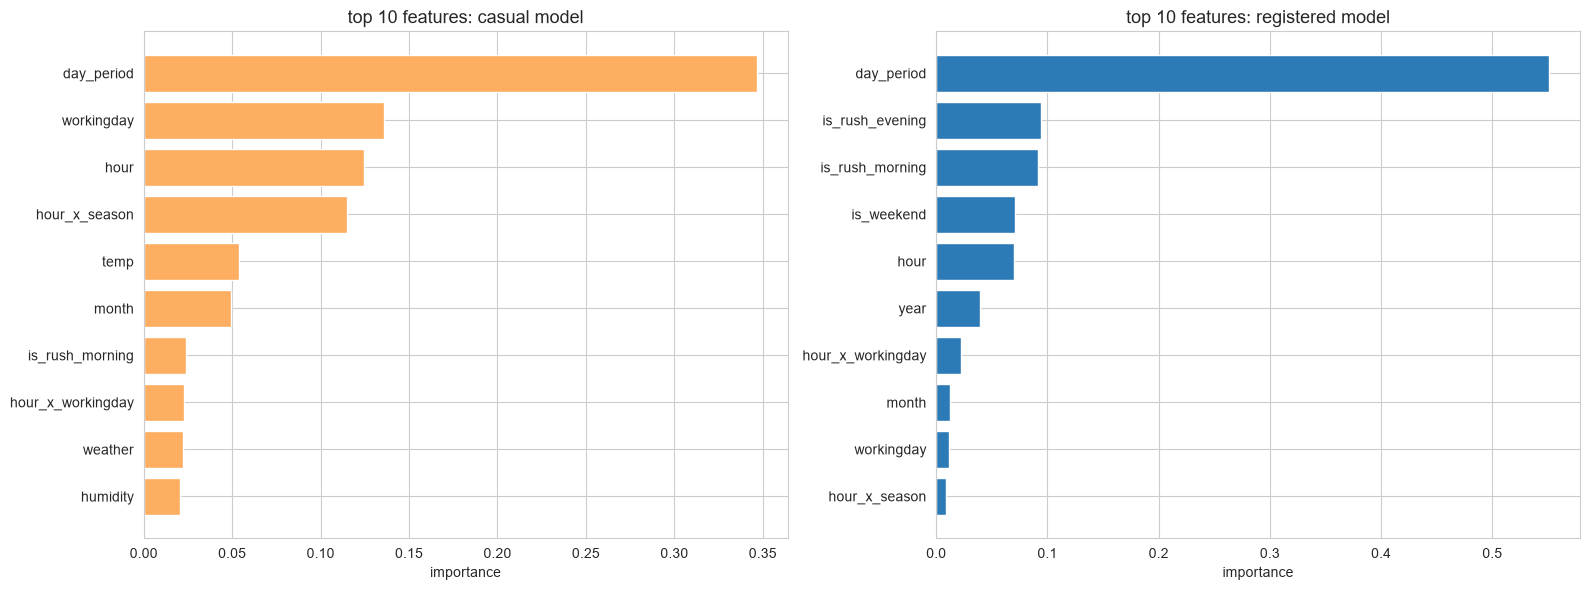

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# casual 模型的特征重要性
imp_casual = xgb_search_casual.best_estimator_.feature_importances_
indices_c = np.argsort(imp_casual)[-10:]
axes[0].barh(range(10), imp_casual[indices_c], color="#fdae61", edgecolor="white")
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features[i] for i in indices_c])
axes[0].set_xlabel("importance")
axes[0].set_title("top 10 features: casual model", fontsize=13)

# registered 模型的特征重要性
imp_registered = xgb_search_registered.best_estimator_.feature_importances_
indices_r = np.argsort(imp_registered)[-10:]
axes[1].barh(range(10), imp_registered[indices_r], color="#2c7bb6", edgecolor="white")
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features[i] for i in indices_r])
axes[1].set_xlabel("importance")
axes[1].set_title("top 10 features: registered model", fontsize=13)

plt.tight_layout()
plt.savefig("output/figures/feature-importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# === 对比分析：casual vs registered 特征差异 ===
print('=== casual top 5 ===')
for i in indices_c[::-1][:5]:
    print(f'  {features[i]:20s}  {imp_casual[i]:.4f}')

print('\n=== registered top 5 ===')
for i in indices_r[::-1][:5]:
    print(f'  {features[i]:20s}  {imp_registered[i]:.4f}')

=== casual top 5 ===
  day_period            0.3466
  workingday            0.1358
  hour                  0.1244
  hour_x_season         0.1150
  temp                  0.0540

=== registered top 5 ===
  day_period            0.5513
  is_rush_evening       0.0942
  is_rush_morning       0.0919
  is_weekend            0.0704
  hour                  0.0697


### 8.3 模型解释

XGBoost 内置的特征重要性已经在上面的分析中展示。如果要进一步做 SHAP 分析，需要安装兼容版本的依赖（当前环境 numpy 2.5 + numba 0.66 不兼容，SHAP 不可用）。

不过从特征重要性里已经能读出足够的信息：对于 casual 模型，`day_period`、`workingday`、`hour`、`hour_x_season` 是主导变量；对于 registered 模型，`day_period`、高峰标记和 `is_weekend` 排在前面。这和 EDA 阶段的观察完全吻合——两类用户由不同的因素驱动。

In [ ]:
# SHAP 分析在当前环境（numpy 2.5 + numba 0.66）不可用
# import shap  # ← 会触发 ImportError: Numba needs NumPy 2.4 or less
# 如需 SHAP：先运行 pip install numpy==2.4.0

print("SHAP 分析已跳过（依赖不兼容）。请参考上方 XGBoost feature_importance。")

### 8.4 城市出行洞察

回到最初的分析视角——从数据里看一座城市的作息规律。

#### 通勤 vs 休闲：两种骑行节奏

registered 用户（通勤族）的行为像一个定时闹钟：工作日的 7-9 点和 17-19 点准时出现两个高峰，一年四季雷打不动。天气对他们有影响，但不大——下雨天少骑一点，但该上班还得上班。

casual 用户（休闲族）完全不一样。他们喜欢在周末的午后出门，遇到好天气蜂拥而出，下雨或太冷就几乎为零。他们的骑行量对温度的弹性远超 registered。

#### 天气说了算，但不是全部

温度和湿度是最重要的天气变量，但风和极端天气的影响相对有限。原因很朴素：DC 大部分日子天气都还行，真正让骑车人犹豫的不是"要不要带伞"，而是"外面冷不冷"。

#### 2012 年发生了什么

2012 年的租车量比 2011 年高了约 70%。共享单车在 DC 进入了快速普及期——这个趋势本身就是很强的预测信号。如果把 2011 年的模式不加调整地用在 2012 年，会系统性低估。

#### 小时是最强的维度

在所有特征中，`hour` 和 `hour_x_workingday` 始终排在重要度前三。一天 24 小时的节奏，是这座城市的呼吸频率。

### 8.5 复盘与后续方向

**v1→v2 做了什么：**

1. **循环编码**（最重要的一步）— hour/month/weekday 的 sin/cos 变换让模型正确理解了时间的循环性。23 点离 0 点只有 1 小时，不是 23 小时
2. **atemp 替代 temp** — 体感温度对"要不要骑车"的影响比温度计数字更直接
3. **weather=4 去噪** — 1 条样本的类别并入 weather=3
4. **调参搜索加倍** — XGB/LGB 50→100 组，RF 30→50 组
5. **修复模型选择逻辑** — v1 盲目用了 Stacking（0.3958），忽略了调参后 XGBoost（0.3779）。v2 自动对比所有策略选最优
6. **workingday × weather 交互** — 坏天气对工作日和周末的影响不同

**还可以尝试的方向：**

- 构造 weekend × hour 的二阶交互（周末的"早晚高峰"定义跟工作日不同）
- 用 Optuna 替代 RandomizedSearchCV，做更聪明的超参搜索
- 对天气条件的非线性效应建模（temp² 或分段线性）
- 引入 XGBoost GPU 加速（RTX 3070 Ti 闲置中）

---

### 8.6 框架迁移

这套分析框架（时间序列分解 → 行为分群 → 分头建模 → 集成）可以迁移到任何"需要预测时序需求量"的场景：

- 外卖平台的订单量预测（午餐 vs 晚餐 vs 夜宵 = casual vs registered）
- 充电桩的使用率预测（通勤充电 vs 长途充电）
- 公共交通的客流预测

核心思路是不变的：**先理解数据里的行为模式，再设计模型去匹配它，而不是反过来让数据去迁就模型**。

---

以上就是 Bike Sharing Demand 分析的完整过程。感谢阅读。